# Bathymetry slope

Calculating the bathymetric slope in each Panan resolution. That will be used to transpose U,V into along and cross slope components later.


[Adapted from OM2 to panan from this GH code, Original code by Wilma Huneke, modified by Wilton Aguiar](https://github.com/wghuneke/ASC_SpatialTemporalVariability/blob/main/notebooks/Calc_ASCcoord_transform_ocean.ipynb)


### First, load in python modules

In [2]:
# Standard modules
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import netCDF4 as nc
import xarray as xr
import numpy as np
from dask.distributed import Client

# Optional modules
import cmocean as cm
#import xarray.ufuncs as xu
import matplotlib.path as mpath
import cartopy.crs as ccrs
import xgcm
import matplotlib.colors as colors
from scipy.interpolate import griddata

# For metpy function
# (use the conda3 unstable kernel)
from metpy.interpolate import cross_section
#from metpy.interpolate import interpolate_to_slice

# Ignore warnings
import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

Start a cluster with multiple cores

In [3]:
client = Client(memory_limit='1020GiB') 
client

2024-04-29 12:14:16,757 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 1020GiB due to system memory limit of 0.98 TiB
2024-04-29 12:14:16,762 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 1020GiB due to system memory limit of 0.98 TiB
2024-04-29 12:14:16,766 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 1020GiB due to system memory limit of 0.98 TiB
2024-04-29 12:14:16,771 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 1020GiB due to system memory limit of 0.98 TiB
2024-04-29 12:14:16,775 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 1020GiB due to system memory limit of 0.98 TiB
2024-04-29 12:14:16,779 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 1020GiB due to system memory limit of 0.98 TiB
2024-04-29 12:14:16,783 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 1020GiB due to system memory limit of 0.98 TiB


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:38045/status,
Dashboard: http://127.0.0.1:38045/status,Workers: 7
Total threads: 28,Total memory: 6.88 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33173,Workers: 7
Dashboard: http://127.0.0.1:38045/status,Total threads: 28
Started: Just now,Total memory: 6.88 TiB
Comm: tcp://127.0.0.1:44637,Total threads: 4
Dashboard: http://127.0.0.1:41731/status,Memory: 0.98 TiB
Nanny: tcp://127.0.0.1:36243,


Nominate a database from wich to load the data and define an experiment

In [4]:
# Load database
session = cc.database.create_session()
# Define experiment in database
expt = 'panant-0025-zstar-ACCESSyr2'

### Load data

In [5]:
lat_slice = slice(-90, -59)

start_time = '2000-01-01'
end_time   = '2000-01-02'#'2086-12-31'

Load bathymetry

In [6]:
# Import bathymetry - previously calculated based on last cell on t
#######################################################################
# !IMPORTANT: The commented lines below were used to produce the discretized bathymetry, which is not useful for slope calculations
#              the correct method should use deptho to calculate the bathrymetry since that is undiscretized bath
##################################################################################################################
##for panan01 - Notice we are using the bathymetry at the t point, ...
##...which would likely differ to the bathymetry at the u points...
##Bu since we dont have variables at xq,yq in panan , we cant evaluate that
## temp_005=cc.querying.getvar(expt, 'thetao', session, n=1,chunks={'xh':'100gb','yh':'100gb'}).isel(time=0)
# depth_array_005 = temp_005 * 0 + temp_005.z_l
## ht_005 = depth_array_005.max(dim = 'z_l', skipna= True)
## ht_0025.to_netcdf('/home/156/wf4500/x77_wf4500/ASC_project/model_data/Panan_Maxdepth/HT_0025_full.nc')


## depthfile_005='/home/156/wf4500/x77_wf4500/ASC_project/model_data/Panan_Maxdepth/HT_005_full.nc'
## ht_005=xr.open_dataset(depthfile_005); 
## ht_005=ht_005.__xarray_dataarray_variable__
#####################################################################################################################
ht = cc.querying.getvar(expt, 'deptho', session, n=1)
ht.load()

# hu = cc.querying.getvar(expt, 'hu', session, n=1)
# hu = hu.sel(yu_ocean=lat_slice)  
#ht = ht_01.rename({'xh':'xq'}).rename({'yh':'yq'}).load()
#ht = ht_005.load()

# # lat/lon information
xq = cc.querying.getvar(expt, 'xq', session, n=1)[1:]
yq = cc.querying.getvar(expt, 'yq', session, n=1)[1:]
xh = cc.querying.getvar(expt, 'xh', session, n=1)
yh = cc.querying.getvar(expt, 'yh', session, n=1)
# Forcefully subs into depth
ht['yh']=yh
ht['xh']=xh
#rechuncking
ht=ht.chunk(chunks={'xh':1200,'yh':169})
hu = ht.copy()
hu['xh']=xq.values; hu = hu.rename({'xh':'xq'})
hu['yh']=yq.values; hu = hu.rename({'yh':'yq'})
#hu=ht.interp(xh=xq).interp(yh=yq)

0.3.0
0.3.0
0.3.0
0.3.0
0.3.0


Load velocity

In [10]:
# One day to test - where are our velocities located?
u = cc.querying.getvar(expt, 'uo', session, frequency='1 daily',start_time=start_time, end_time=end_time,chunks={'xq':'100gb','yh':'100gb'})
u = u.sel(time=slice(start_time,end_time)).sel(yh=lat_slice).mean('time').rename({'z_l_sub01':'z_l'})
v = cc.querying.getvar(expt, 'vo', session, frequency='1 daily', start_time=start_time, end_time=end_time,chunks={'xh':'100gb','yq':'100gb'})
v = v.sel(time=slice(start_time,end_time)).sel(yq=lat_slice).mean('time').rename({'z_l_sub01':'z_l'})

0.3.0


Interpolating u to the vgrid, and v to the ugrid.

In [12]:
u_onv=u.interp(xq=xh).interp(yh=yq)
v_onu=v.interp(xh=xq).interp(yq=yh)

Along-slope velocity

In [13]:
maxy = np.size(u.yh)
maxx = np.size(v.xh)
maxx,maxy

(14400, 2038)

In [15]:
path_to_folder = '/g/data/ik11/outputs/mom6-panan/panant-0025-zstar-ACCESSyr2/output000/19910101.ocean_static.nc'

grid = xr.open_mfdataset(path_to_folder, combine='by_coords')
grid = grid.isel(xq=slice(1,maxx+1)).drop_vars('time')
grid = grid.chunk(chunks={'xh':1200,'yh':169})
grid = grid.chunk(chunks={'xq':1200,'yq':169})
grid = grid.drop_vars(('deptho','Coriolis','wet','wet_c','wet_u','wet_v'))

ds = xr.merge([hu, grid])
ds.coords['xh'].attrs.update(axis='X')
ds.coords['xq'].attrs.update(axis='X', c_grid_axis_shift=0.5)
ds.coords['yh'].attrs.update(axis='Y')
ds.coords['yq'].attrs.update(axis='Y', c_grid_axis_shift=0.5)
ds=ds.rename({'deptho':'hu'})
grid = xgcm.Grid(ds, periodic=['X'])


MOM6 differs in MOM5 since the grid is arakawa C. This means taht u,v are not in the same place as in MOM5 (E.g., OM2). We have to take that into account and therefore calculate the slope and dhu in both grid locations. We would need to do that anyways  later on to have the Ualong at the same location as the CSHT, so lets just take care of it rn

In [16]:
# Take gradient and move to u grid
# Simple gradient over one grid cell. 
# In latitudinal direction, we need to specify what happens at the boundary.
#dhu_dx = grid.interp( grid.diff(ds.hu, 'X') / grid.interp(ds.dxu, 'X'), 'X')#, 'Y', boundary='extend')
dhu_dx_v =  grid.diff(ds.hu, 'X') / ds.dxCu.interp(yh=yq).interp(xq=xh) # on v(xh,yq)
#dhu_dx_v =  grid.diff(ds.hu, 'X') / ds.dxCu.interp(yh=yq) # on v(xh,yq)
dhu_dx_u =  grid.diff(ds.hu, 'X').interp(xh=xq).interp(yq=yh) / ds.dxCu# on v(xq,yh)
#dhu_dx_u =  grid.diff(ds.hu, 'X') / ds.dxCu# on v(xq,yh)

#dhu_dy = grid.interp( grid.diff(ds.hu, 'Y', boundary='extend') / grid.interp(ds.dyt, 'X'), 'Y', boundary='extend')# 'X')
dhu_dy_v =  grid.diff(ds.hu, 'X') /ds.dyt.interp(yh=yq)
dhu_dy_u =  grid.diff(ds.hu, 'X').interp(xh=xq).interp(yq=yh) /ds.dyt.interp(xh=xq)

# # Select latitude slice
dhu_dx_v = dhu_dx_v.sel(yq=lat_slice)
dhu_dy_v = dhu_dy_v.sel(yq=lat_slice)
dhu_dx_u = dhu_dx_u.sel(yh=lat_slice)
dhu_dy_u = dhu_dy_u.sel(yh=lat_slice)

# Calculate the magnitude of the topographic slope
#slope = xu.sqrt(dhu_dx**2 + dhu_dy**2)
slope_u = (dhu_dx_u**2 + dhu_dy_u**2)**0.5
slope_v = (dhu_dx_v**2 + dhu_dy_v**2)**0.5

In [17]:
# Along-slope velocity
#u_along = u*dhu_dy/slope - v*dhu_dx/slope
#On ugrid
u_along_ug = u*dhu_dy_u/slope_u - v_onu*dhu_dx_u/slope_u
u_along_ug = u_along_ug.fillna(0)* ((u*0)+1) #(Masking continent)
#u_along = u_along.load()

In [18]:
hu_u = ht.interp(xh=xq)
#for visual check
u_along_ug_abs=abs(u_along_ug.where(hu_u<3000).mean('z_l')).load()

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
 

Text(0.5, 1.0, 'deptho')

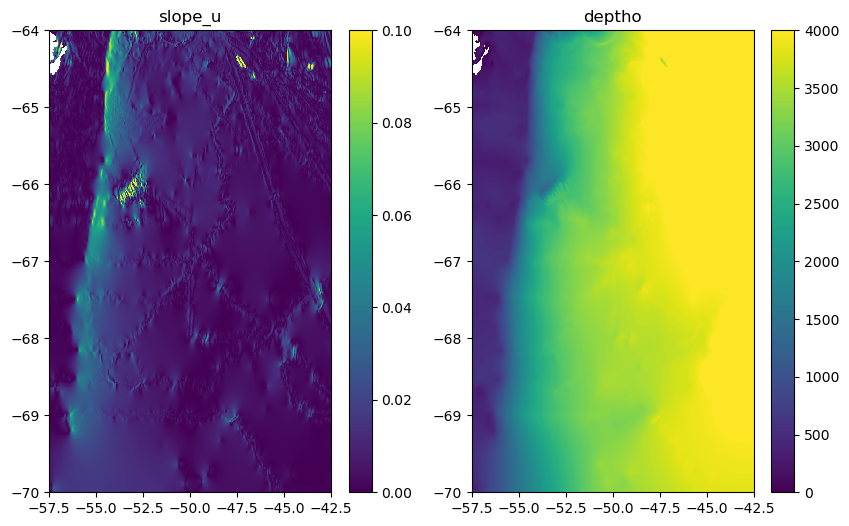

In [19]:
#visual check - somehow it looks a little more chaotic than Id expect
fig = plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.pcolormesh(hu.xq,ht.yh[:maxy],slope_u,vmin=0,vmax=0.1)
plt.xlim(-57.5,-42.5); plt.ylim(-70,-64)
plt.colorbar(); plt.title ('slope_u')

plt.subplot(1,2,2)
plt.pcolormesh(hu.xq,ht.yh,ht,vmin=0,vmax=4000)
plt.xlim(-57.5,-42.5); plt.ylim(-70,-64)
plt.colorbar(); plt.title ('deptho')

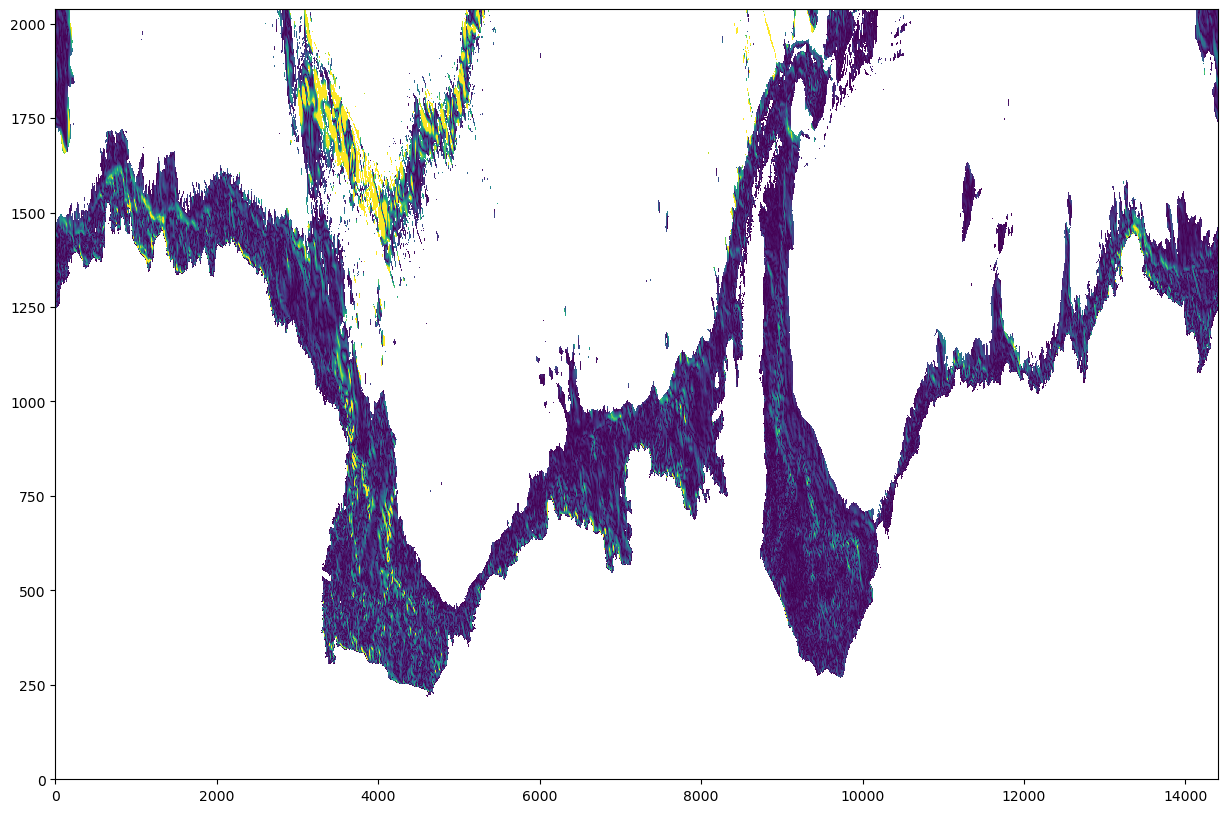

In [23]:
#visual check - somehow it looks a little more chaotic than Id expect
fig = plt.figure(figsize=(15,10))
plt.pcolormesh(u_along_ug_abs,vmin=0,vmax=0.2)


By talking to christina I noticed that the bathymetry is very stepwise. lets look into other models

Saving variables required to transpose u and v into along and cross components

In [22]:
	
	save_dir  = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/slope_transpose_panan0025.nc'
	
	
	data_SU=xr.DataArray(slope_u,name="slope(U-grid)",dims=["yh","xq"])
	data_SV=xr.DataArray(slope_v,name="slope(V-grid)",dims=["yq","xh"])
	data_DDXu=xr.DataArray(dhu_dx_u,name="dhu_dx(U-grid)",dims=["yh","xq"])
	data_DDXv=xr.DataArray(dhu_dx_v,name="dhu_dx(V-grid)",dims=["yq","xh"])
	data_DDYu=xr.DataArray(dhu_dy_u,name="dhu_dy(U-grid)",dims=["yh","xq"])
	data_DDYv=xr.DataArray(dhu_dy_v,name="dhu_dy(V-grid)",dims=["yq","xh"])
	
	
	data_to_saveuv = xr.merge([data_SU,data_SV,data_DDXu,data_DDXv,data_DDYu,data_DDYv])
	
	
	
	
	data_to_saveuv.to_netcdf(save_dir)
	
	print('Finished successful')
	

Finished successful
